## 1. Setup and imports
### 1.1 Experiment setup

This notebook implements a minimal two-client collaborative learning simulation.

- A shared held-out test set is created first.
- The remaining training data is split into two clients.
- Each client receives its own local data stream split into 3 sequential batches.
- Three strategies are compared:
  - local_only
  - full_transfer
  - output_layer_only
- Performance is evaluated on the shared test set after each round.
- Communication cost is approximated using the number of transferred trainable parameters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import typing_extensions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## 2. Load and preprocess data

In [3]:
file_path = "../data/data.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [8]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isna().sum())
target_col = "fail"
print(df[target_col].value_counts())

['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64
fail
0    551
1    393
Name: count, dtype: int64


In [9]:
df_model = df.copy()

# Drop non-feature columns (optional but may be useful for other dataqsets)
drop_cols = []
for col in df_model.columns:
    if "id" in col.lower():
        drop_cols.append(col)

if drop_cols:
    df_model = df_model.drop(columns=drop_cols)

# Encode binary target if needed
if df_model[target_col].dtype == "object":
    unique_vals = df_model[target_col].unique()
    print("Target values:", unique_vals)
    df_model[target_col] = df_model[target_col].astype("category").cat.codes

df_model.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [12]:
print(df_model[target_col].value_counts())
X = df_model.drop(columns=[target_col])
y = df_model[target_col]
print("X shape:", X.shape)
print("y shape:", y.shape)

fail
0    551
1    393
Name: count, dtype: int64
X shape: (944, 9)
y shape: (944,)


## 3. Shared test set and client splits

In [13]:
# Shared test set
X_train_pool, X_test_shared, y_train_pool, y_test_shared = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Remaining training pool split into two clients
X_client1, X_client2, y_client1, y_client2 = train_test_split(
    X_train_pool, y_train_pool,
    test_size=0.5,
    stratify=y_train_pool,
    random_state=42
)

print("Shared test set:", X_test_shared.shape, y_test_shared.shape)
print("Client 1:", X_client1.shape, y_client1.shape)
print("Client 2:", X_client2.shape, y_client2.shape)

print("\nClass balance:")
print("Shared test:")
print(y_test_shared.value_counts(normalize=True).sort_index())
print("\nClient 1:")
print(y_client1.value_counts(normalize=True).sort_index())
print("\nClient 2:")
print(y_client2.value_counts(normalize=True).sort_index())

Shared test set: (189, 9) (189,)
Client 1: (377, 9) (377,)
Client 2: (378, 9) (378,)

Class balance:
Shared test:
fail
0    0.582011
1    0.417989
Name: proportion, dtype: float64

Client 1:
fail
0    0.583554
1    0.416446
Name: proportion, dtype: float64

Client 2:
fail
0    0.584656
1    0.415344
Name: proportion, dtype: float64


## 4. Clients split into sequential batches

In [14]:
def split_into_sequential_batches(X_df, y_series, n_batches=3):
    batch_size = len(X_df) // n_batches
    batches = []

    for i in range(n_batches):
        start = i * batch_size
        end = (i + 1) * batch_size if i < n_batches - 1 else len(X_df)

        X_batch = X_df.iloc[start:end].copy()
        y_batch = y_series.iloc[start:end].copy()

        batches.append((X_batch, y_batch))

    return batches


n_rounds = 3

client1_batches = split_into_sequential_batches(X_client1.reset_index(drop=True),
                                                y_client1.reset_index(drop=True),
                                                n_batches=n_rounds)

client2_batches = split_into_sequential_batches(X_client2.reset_index(drop=True),
                                                y_client2.reset_index(drop=True),
                                                n_batches=n_rounds)

for i, ((Xb1, yb1), (Xb2, yb2)) in enumerate(zip(client1_batches, client2_batches), start=1):
    print(f"Round {i}")
    print("  Client 1 batch:", Xb1.shape, yb1.shape, "| class counts:", yb1.value_counts().to_dict())
    print("  Client 2 batch:", Xb2.shape, yb2.shape, "| class counts:", yb2.value_counts().to_dict())

Round 1
  Client 1 batch: (125, 9) (125,) | class counts: {0: 74, 1: 51}
  Client 2 batch: (126, 9) (126,) | class counts: {0: 71, 1: 55}
Round 2
  Client 1 batch: (125, 9) (125,) | class counts: {0: 78, 1: 47}
  Client 2 batch: (126, 9) (126,) | class counts: {0: 73, 1: 53}
Round 3
  Client 1 batch: (127, 9) (127,) | class counts: {0: 68, 1: 59}
  Client 2 batch: (126, 9) (126,) | class counts: {0: 77, 1: 49}


## 5. MLP model

In [15]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

## 6. Helper functions
### 6.1 Scaling and tensor conversion

In [16]:
def fit_scaler_on_train_pool(X_train_pool):
    scaler = StandardScaler()
    scaler.fit(X_train_pool)
    return scaler


def to_tensor_dataset(X_df, y_series, scaler):
    X_scaled = scaler.transform(X_df)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.values.reshape(-1, 1), dtype=torch.float32)
    return TensorDataset(X_tensor, y_tensor)

### 6.2 Local training and eveluation

In [17]:
def train_one_batch(model, X_batch, y_batch, scaler, epochs=20, lr=0.01, batch_size=32):
    model.train()

    dataset = to_tensor_dataset(X_batch, y_batch, scaler)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()


def evaluate_model(model, X_eval, y_eval, scaler):
    model.eval()

    X_scaled = scaler.transform(X_eval)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    y_true = y_eval.values

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }

### 6.3 Transfer / averaging helpers

In [18]:
def average_full_models(model_a, model_b):
    new_model = deepcopy(model_a)
    state_a = model_a.state_dict()
    state_b = model_b.state_dict()

    averaged_state = {}
    for key in state_a:
        averaged_state[key] = (state_a[key] + state_b[key]) / 2.0

    new_model.load_state_dict(averaged_state)
    return new_model


def average_output_layer_only(model_a, model_b):
    new_model_a = deepcopy(model_a)
    new_model_b = deepcopy(model_b)

    with torch.no_grad():
        avg_weight = (model_a.output.weight.data + model_b.output.weight.data) / 2.0
        avg_bias = (model_a.output.bias.data + model_b.output.bias.data) / 2.0

        new_model_a.output.weight.data.copy_(avg_weight)
        new_model_a.output.bias.data.copy_(avg_bias)

        new_model_b.output.weight.data.copy_(avg_weight)
        new_model_b.output.bias.data.copy_(avg_bias)

    return new_model_a, new_model_b

### 6.4 Parameter count helpers

In [19]:
def count_total_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_output_layer_params(model):
    return sum(p.numel() for p in model.output.parameters() if p.requires_grad)

### 6.5 Experiment runner

In [20]:
def run_collaborative_experiment(mode, client1_batches, client2_batches,
                                 X_test_shared, y_test_shared,
                                 X_train_pool, input_dim,
                                 epochs=20, lr=0.01):
    torch.manual_seed(42)
    np.random.seed(42)

    scaler = fit_scaler_on_train_pool(X_train_pool)

    base_model = SimpleMLP(input_dim)
    client1_model = deepcopy(base_model)
    client2_model = deepcopy(base_model)

    results = []

    total_params = count_total_params(base_model)
    output_params = count_output_layer_params(base_model)

    cumulative_transfer_cost = 0

    for round_idx, ((Xb1, yb1), (Xb2, yb2)) in enumerate(zip(client1_batches, client2_batches), start=1):
        # local updates
        train_one_batch(client1_model, Xb1, yb1, scaler, epochs=epochs, lr=lr)
        train_one_batch(client2_model, Xb2, yb2, scaler, epochs=epochs, lr=lr)

        # collaboration step
        if mode == "local_only":
            round_transfer_cost = 0

        elif mode == "full_transfer":
            shared_model = average_full_models(client1_model, client2_model)
            client1_model = deepcopy(shared_model)
            client2_model = deepcopy(shared_model)
            round_transfer_cost = 2 * total_params

        elif mode == "output_layer_only":
            client1_model, client2_model = average_output_layer_only(client1_model, client2_model)
            round_transfer_cost = 2 * output_params

        else:
            raise ValueError(f"Unknown mode: {mode}")

        cumulative_transfer_cost += round_transfer_cost

        # evaluate both clients on shared test set
        metrics_c1 = evaluate_model(client1_model, X_test_shared, y_test_shared, scaler)
        metrics_c2 = evaluate_model(client2_model, X_test_shared, y_test_shared, scaler)

        # average the two clients' metrics for one round summary
        round_result = {
            "mode": mode,
            "round": round_idx,
            "accuracy": (metrics_c1["accuracy"] + metrics_c2["accuracy"]) / 2,
            "precision": (metrics_c1["precision"] + metrics_c2["precision"]) / 2,
            "recall": (metrics_c1["recall"] + metrics_c2["recall"]) / 2,
            "f1": (metrics_c1["f1"] + metrics_c2["f1"]) / 2,
            "round_transfer_cost": round_transfer_cost,
            "cumulative_transfer_cost": cumulative_transfer_cost,
        }

        results.append(round_result)

    return pd.DataFrame(results)

## 7. Experiment for each mode

In [21]:
input_dim = X.shape[1]

results_local = run_collaborative_experiment(
    mode="local_only",
    client1_batches=client1_batches,
    client2_batches=client2_batches,
    X_test_shared=X_test_shared,
    y_test_shared=y_test_shared,
    X_train_pool=X_train_pool,
    input_dim=input_dim,
    epochs=20,
    lr=0.01
)

results_full = run_collaborative_experiment(
    mode="full_transfer",
    client1_batches=client1_batches,
    client2_batches=client2_batches,
    X_test_shared=X_test_shared,
    y_test_shared=y_test_shared,
    X_train_pool=X_train_pool,
    input_dim=input_dim,
    epochs=20,
    lr=0.01
)

results_partial = run_collaborative_experiment(
    mode="output_layer_only",
    client1_batches=client1_batches,
    client2_batches=client2_batches,
    X_test_shared=X_test_shared,
    y_test_shared=y_test_shared,
    X_train_pool=X_train_pool,
    input_dim=input_dim,
    epochs=20,
    lr=0.01
)

## 8. Results table

In [22]:
all_results_df = pd.concat(
    [results_local, results_full, results_partial],
    ignore_index=True
)

all_results_df

,mode,round,accuracy,precision,recall,f1,round_transfer_cost,cumulative_transfer_cost
0,local_only,1,0.907407,0.886788,0.892405,0.889579,0,0
1,local_only,2,0.912698,0.888623,0.905063,0.896690,0,0
2,local_only,3,0.912698,0.889241,0.905063,0.896381,0,0
3,full_transfer,1,0.904762,0.886076,0.886076,0.886076,354,354
4,full_transfer,2,0.936508,0.924051,0.924051,0.924051,354,708
5,full_transfer,3,0.915344,0.879518,0.924051,0.901235,354,1062
6,output_layer_only,1,0.907407,0.886788,0.892405,0.889579,34,34
7,output_layer_only,2,0.915344,0.894465,0.905063,0.899593,34,68
8,output_layer_only,3,0.912698,0.888528,0.905063,0.896295,34,102


In [23]:
summary_df = all_results_df.groupby("mode").agg({
    "accuracy": "last",
    "precision": "last",
    "recall": "last",
    "f1": "last",
    "cumulative_transfer_cost": "last"
}).reset_index()

summary_df

,mode,accuracy,precision,recall,f1,cumulative_transfer_cost
0,full_transfer,0.915344,0.879518,0.924051,0.901235,1062
1,local_only,0.912698,0.889241,0.905063,0.896381,0
2,output_layer_only,0.912698,0.888528,0.905063,0.896295,102


## 9. Plot for F1 and transfer cost

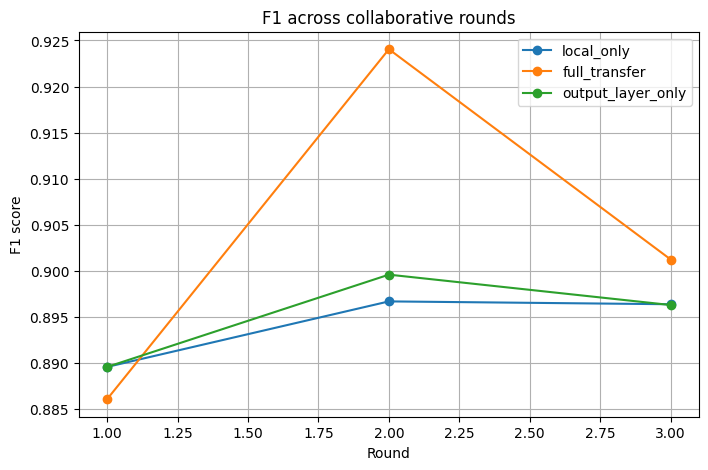

In [24]:
plt.figure(figsize=(8, 5))
for mode in all_results_df["mode"].unique():
    subset = all_results_df[all_results_df["mode"] == mode]
    plt.plot(subset["round"], subset["f1"], marker="o", label=mode)

plt.xlabel("Round")
plt.ylabel("F1 score")
plt.title("F1 across collaborative rounds")
plt.legend()
plt.grid(True)
plt.show()

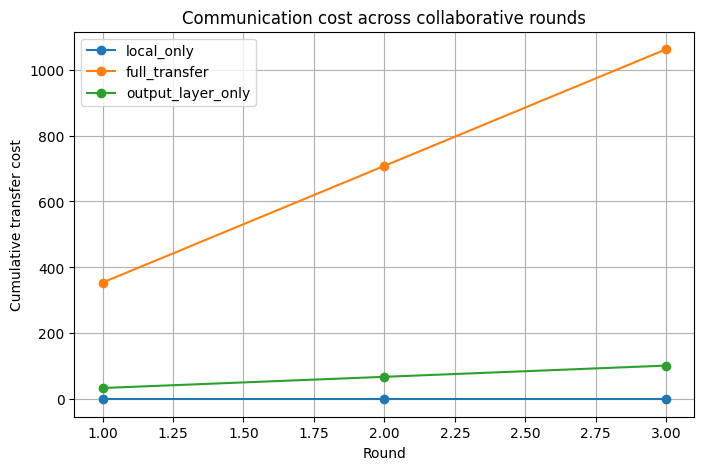

In [25]:
plt.figure(figsize=(8, 5))
for mode in all_results_df["mode"].unique():
    subset = all_results_df[all_results_df["mode"] == mode]
    plt.plot(subset["round"], subset["cumulative_transfer_cost"], marker="o", label=mode)

plt.xlabel("Round")
plt.ylabel("Cumulative transfer cost")
plt.title("Communication cost across collaborative rounds")
plt.legend()
plt.grid(True)
plt.show()

## 10. Short interpretation
In this initial two-client simulation, full-model collaboration provided the strongest short-term improvement in F1, peaking at 0.924 in round 2. By contrast, output-layer-only transfer remained very close to the local-only baseline, suggesting that in this setup most useful shared information resided in earlier representations rather than only in the classifier head. However, output-layer-only transfer reduced communication cost substantially, indicating a possible efficiency tradeoff even when performance gains are limited.

Here are the main take-aways:
- Two-client collaboartive setup works
- Three strategies are meaningfully comparible
- Full transfer performed better than partial transfer in this run.
- Output-layer-only drastically reduced communication cost but but produced little measurable gain over local-only model.

In [26]:
all_results_df.to_csv("../results/two_client_all_results.csv", index=False)
summary_df.to_csv("../results/two_client_summary.csv", index=False)

print("Saved results to ../results/")

Saved results to ../results/
